In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np
import re
import os

#from curated_scratch.ComputeIsotropyMetrics_scratch import pmt_sets, all_pos_cart


def cartesian_to_spherical(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    phi = np.arctan2(y, x)
    theta = np.arccos(z / r)
    return r, phi, theta

def convert_points_to_spherical(points):
    points_set_polars = []
    for point in points:
        x = point[0]
        y = point[1]
        z = point[2]
        r, phi, theta = cartesian_to_spherical(x, y, z)
        points_set_polars.append((r, phi, theta))
    return np.array(points_set_polars)


def spherical_to_cartesian(r, phi, theta):
    x = r * np.cos(phi) * np.sin(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(theta)
    return x, y, z

def convert_points_to_cartesian(points):
    points_set_cartesians = []
    for point in points:
        r = point[0]
        phi = point[1]
        theta = point[2]
        x, y, z = spherical_to_cartesian(r, phi, theta)
        points_set_cartesians.append((x, y, z))
    return np.array(points_set_cartesians)

#function that computes the angle between two vectors

def angle_between_vectors(v1, v2):
    dot_product = np.dot(v1, v2)
    magnitude_v1 = np.linalg.norm(v1)
    magnitude_v2 = np.linalg.norm(v2)
    cosine_angle = dot_product / (magnitude_v1 * magnitude_v2)
    angle_rad = np.arccos(np.clip(cosine_angle, -1.0, 1.0))
    return angle_rad


def peak_value(N, alpha):
    return N * (1 - np.cos(alpha)) / 2

# Function to save indices to .txt file

def save_indices_to_file(indices, pmt_set_num):
    filename = f"random_indices_PMTSet{pmt_set_num}.txt"
    np.savetxt(filename, indices, fmt='%d')
    print(f"Saved random indices for PMTSet {pmt_set_num} to {filename}\n")

def bowley_skewness(data):
    q1 = np.percentile(data, 25)
    q2 = np.percentile(data, 50)  # Median
    q3 = np.percentile(data, 75)
    return (q3 - 2 * q2 + q1) / (q3 - q1)


def moors_kurtosis(data):
    p12_5 = np.percentile(data, 12.5)
    p37_5 = np.percentile(data, 37.5)
    p62_5 = np.percentile(data, 62.5)
    p87_5 = np.percentile(data, 87.5)
    p25 = np.percentile(data, 25)
    p75 = np.percentile(data, 75)

    return ((p87_5 - p12_5) + (p62_5 - p37_5)) / (p75 - p25)


def get_active_positions(indices_file, all_pos_cart, all_pos_sph):
    indices = np.loadtxt(indices_file, dtype=int)
    print(indices.shape)
    print(all_pos_cart.shape)
    print(all_pos_sph.shape)
    active_positions_cart = all_pos_cart[indices]
    active_positions_sph = all_pos_sph[indices]
    return active_positions_cart, active_positions_sph

def compute_config_stats(active_pos_cart, active_pos_sph, nodes_pos_cart, nodes_pos_sph, set_name):
    # Create a new plot of all PMTs and Nodes
    plt.scatter(active_pos_sph[:, 1], active_pos_sph[:, 2], s=0.5, color='blue')  # Original points
    plt.scatter(nodes_pos_sph[:, 1], nodes_pos_sph[:, 2], s=3, color='red', label='Cap Nodes')  # Clicked points in red

    plt.xlabel('Phi')
    plt.ylabel('Theta')
    plt.title('PMTs and Nodes')

ModuleNotFoundError: No module named 'curated_scratch.ComputeIsotropyMetrics_scratch'

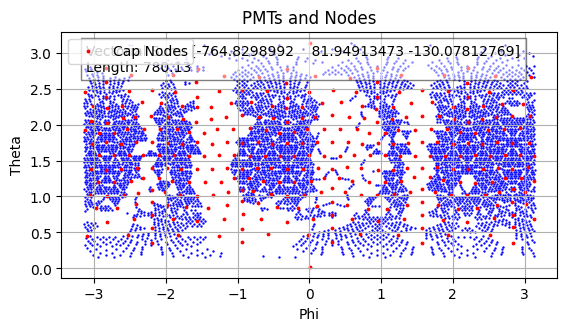

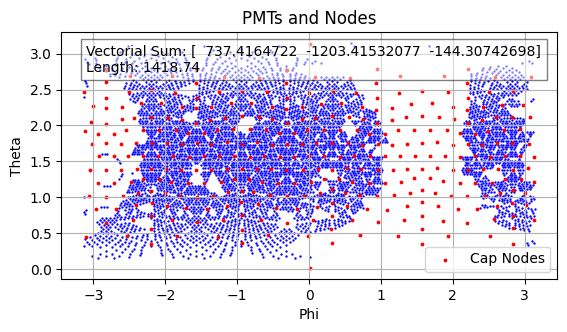

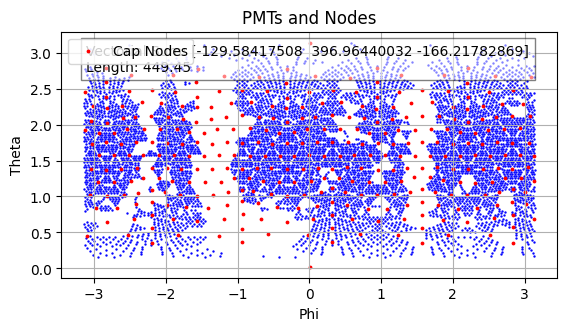

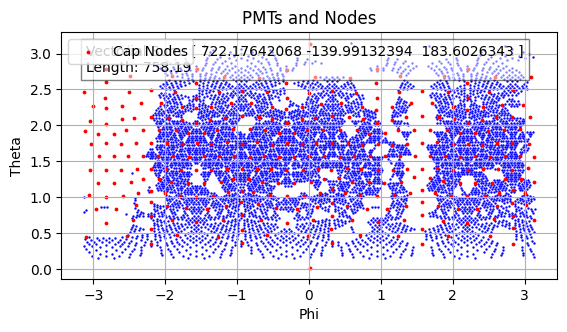

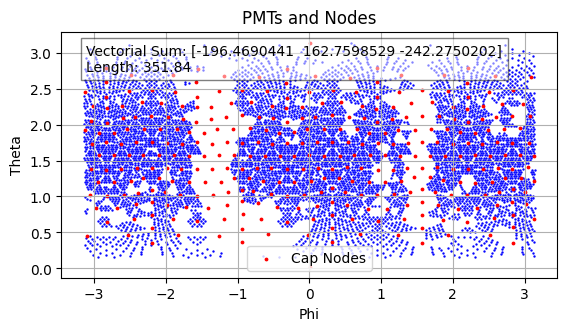

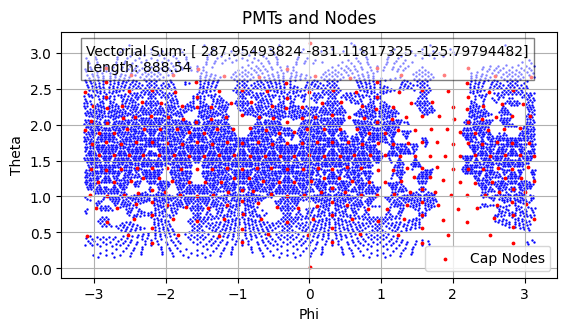

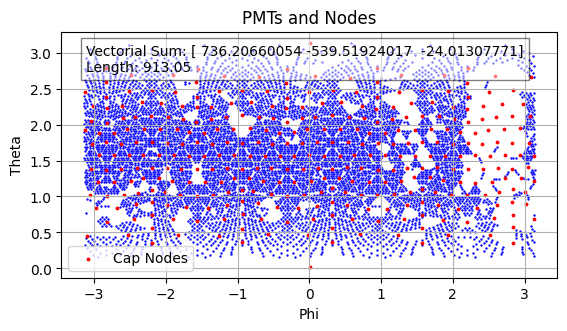

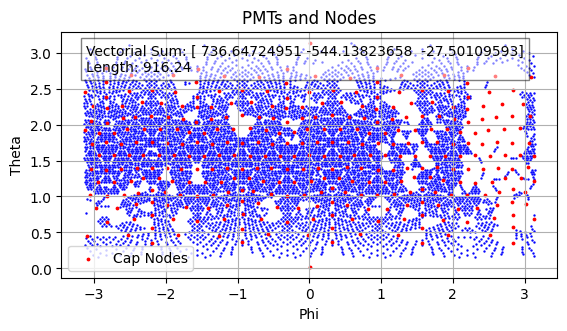

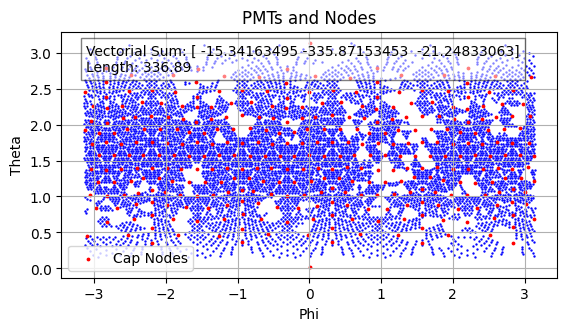

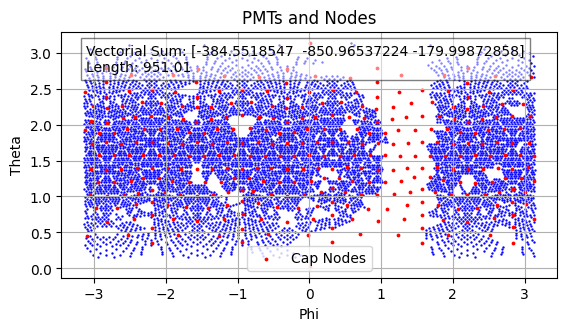

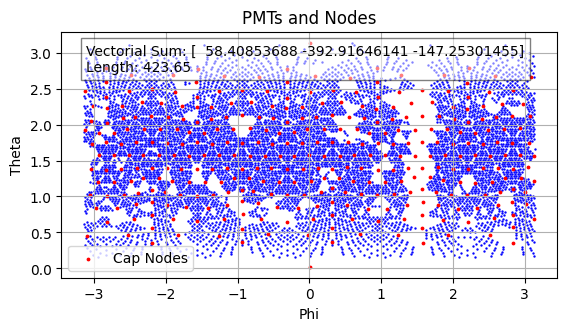

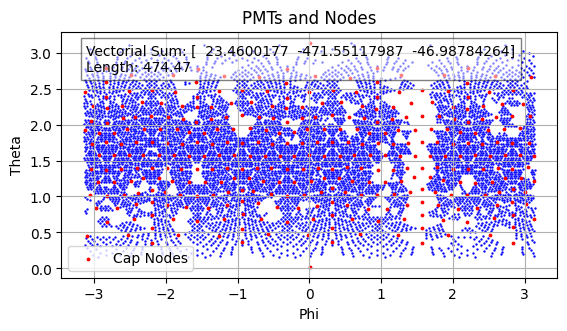

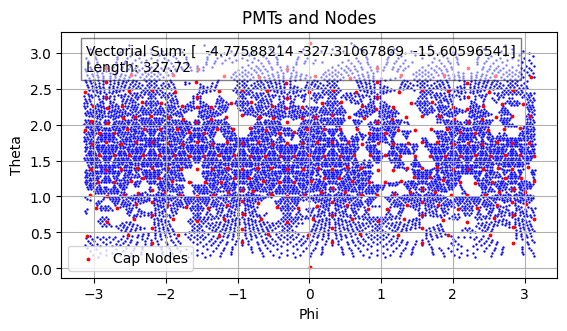

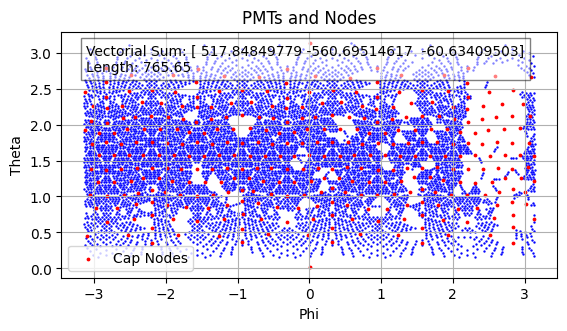

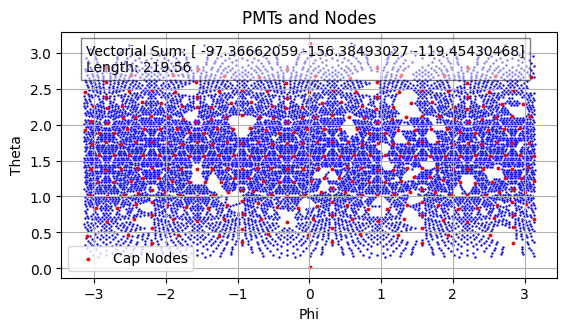

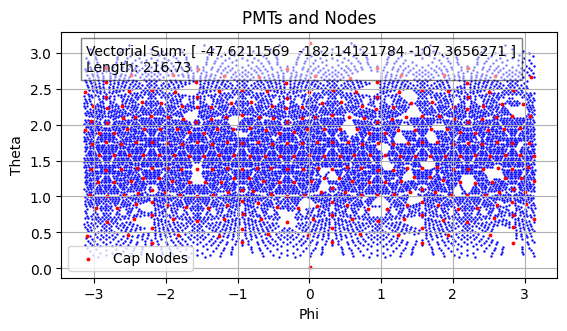

In [16]:
run_set = [309434, 302640, 309504,302159, 355216, 356009, 351884, 351847,
           358123, 303334, 311222, 355145, 358230, 304616, 302948,300515]
### TO DO!!! I missed the last one!!! not sure what happened but I should find it and rerun some things ...

nodes_pos_sph = np.genfromtxt('More_Nodes_Grid.csv', delimiter=',', skip_header=1)
nodes_pos_cart = convert_points_to_cartesian(nodes_pos_sph)

for run_number in run_set:
    active_pos_sph = np.genfromtxt(f'PMTConfigInfoFiles/{str(run_number)}_phi_theta.csv', delimiter=',', skip_header=1)
    active_pos_cart = convert_points_to_cartesian(active_pos_sph)

    vector_sum = np.sum(active_pos_cart, axis=0)
    vector_sum_length = np.linalg.norm(vector_sum)

    # Create a new plot of all PMTs and Nodes
    plt.scatter(active_pos_sph[:,1], active_pos_sph[:,2], s=0.5, color='blue')  # Original points
    plt.scatter(nodes_pos_sph[:,1], nodes_pos_sph[:,2], s=3, color='red', label='Cap Nodes')  # Clicked points in red

    plt.xlabel('Phi')
    plt.ylabel('Theta')
    plt.title('PMTs and Nodes')

    # Add a text box with the value of vectorial_sum and its length
    text = f'Vectorial Sum: {vector_sum}\nLength: {vector_sum_length:.2f}'
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, va='top', bbox=dict(facecolor='white', alpha=0.5))

    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True)
    plt.legend()

    plt.savefig(f'{str(run_number)}_map.pdf', format='pdf')

    plt.show()

    # Add a row to the stats file with 'vector sum norm'
    stats_file = f'PMTConfigStatsFiles/{run_number}_stats.csv'
    if os.path.exists(stats_file):
        df = pd.read_csv(stats_file)
        # Create a new row with 'vector sum norm' as the first entry and vector_sum_length for all columns
        new_row = ['vector sum norm'] + [vector_sum_length] * (len(df.columns) - 1)
        # Append the new row to the dataframe
        df.loc[len(df)] = new_row
        # Save the updated file
        df.to_csv(stats_file, index=False)

(9389,)
(9389, 3)
(9389, 3)


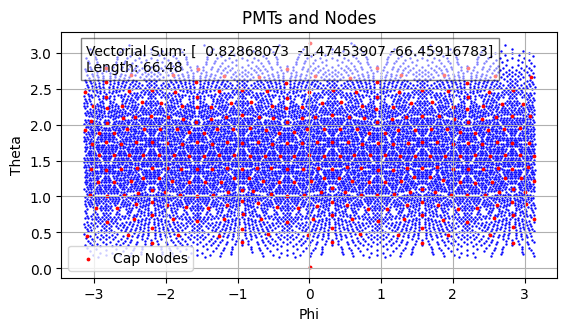

(8989,)
(9389, 3)
(9389, 3)


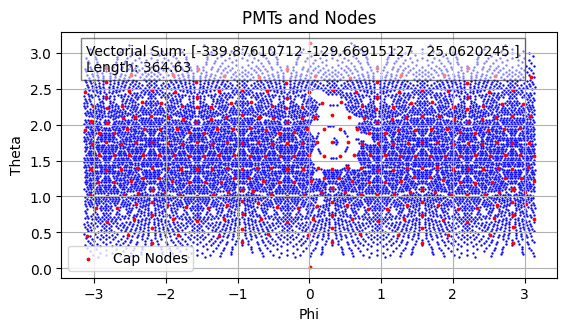

(8589,)
(9389, 3)
(9389, 3)


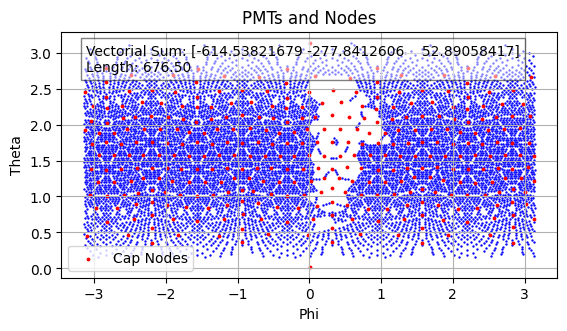

(8189,)
(9389, 3)
(9389, 3)


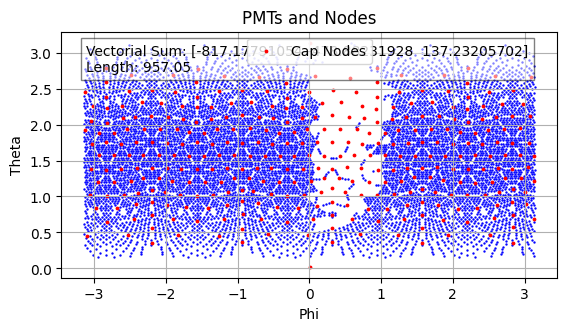

(7789,)
(9389, 3)
(9389, 3)


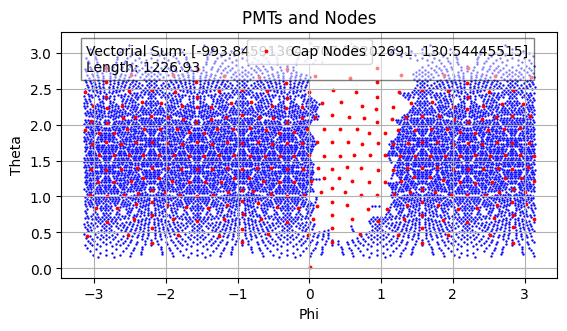

(7389,)
(9389, 3)
(9389, 3)


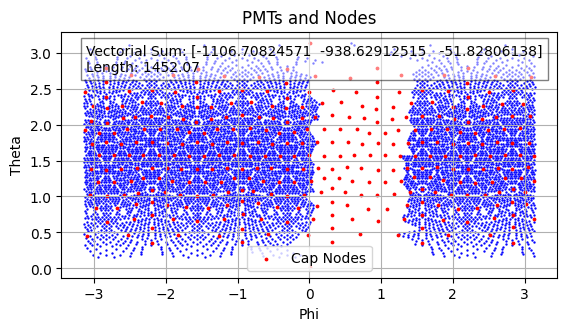

(6889,)
(9389, 3)
(9389, 3)


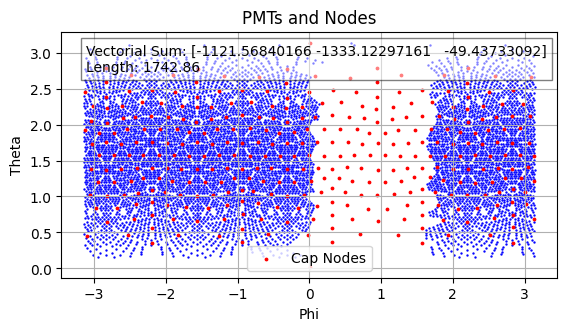

(6389,)
(9389, 3)
(9389, 3)


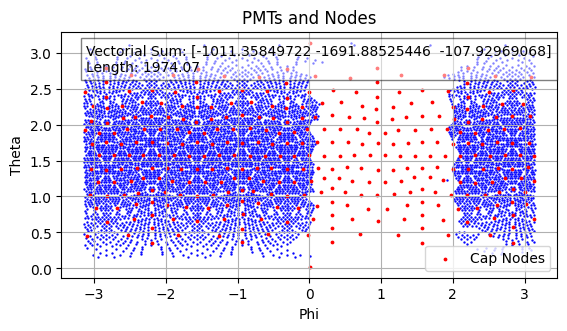

(5889,)
(9389, 3)
(9389, 3)


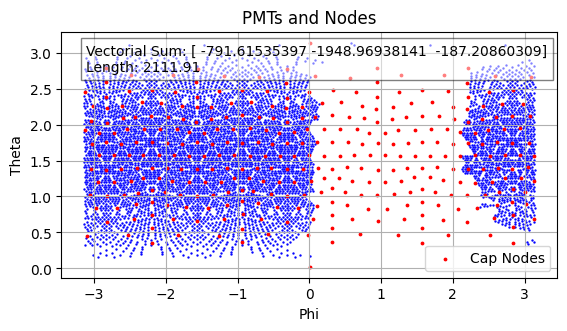

(5389,)
(9389, 3)
(9389, 3)


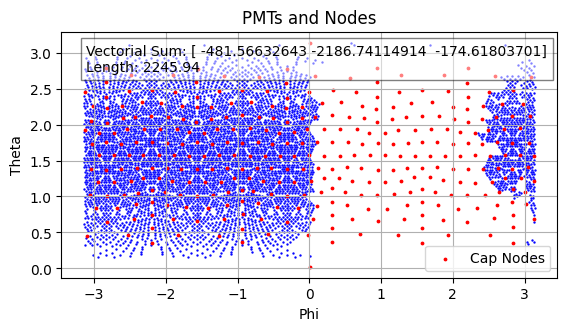

(4889,)
(9389, 3)
(9389, 3)


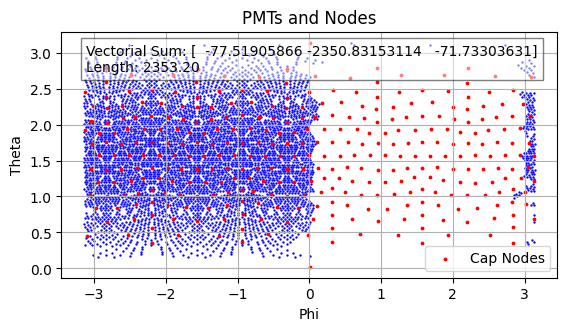

(4389,)
(9389, 3)
(9389, 3)


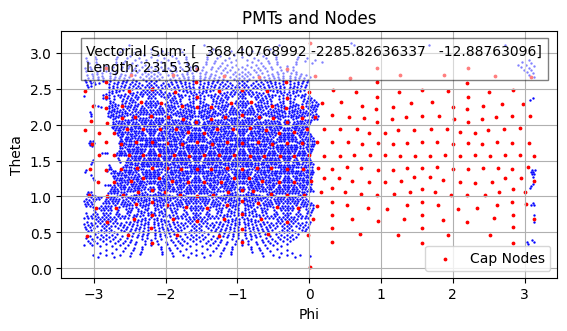

(3889,)
(9389, 3)
(9389, 3)


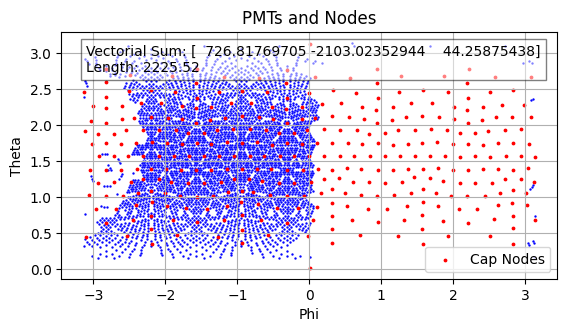

(3389,)
(9389, 3)
(9389, 3)


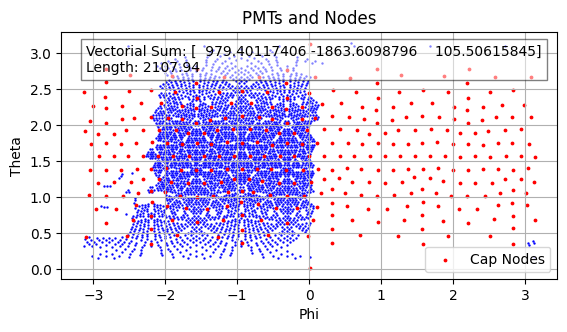

(2389,)
(9389, 3)
(9389, 3)


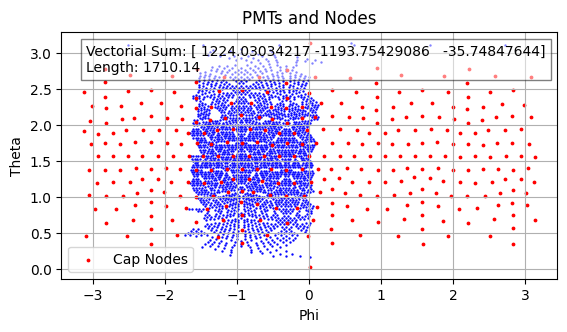

(8989,)
(9389, 3)
(9389, 3)


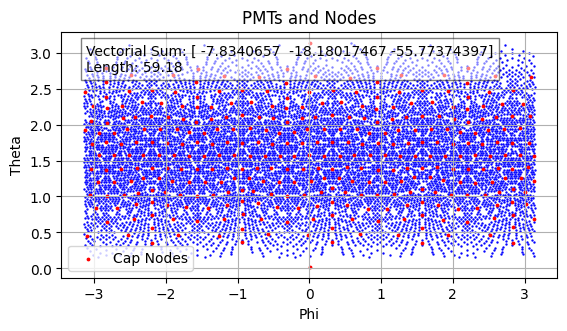

(8589,)
(9389, 3)
(9389, 3)


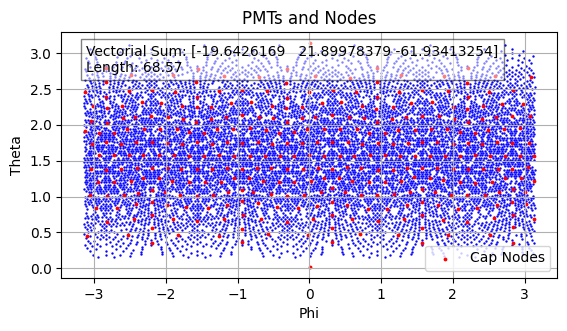

(8189,)
(9389, 3)
(9389, 3)


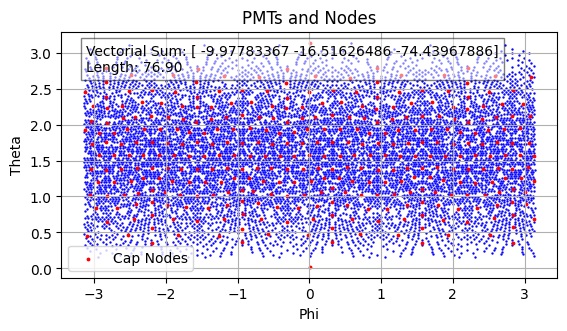

(7789,)
(9389, 3)
(9389, 3)


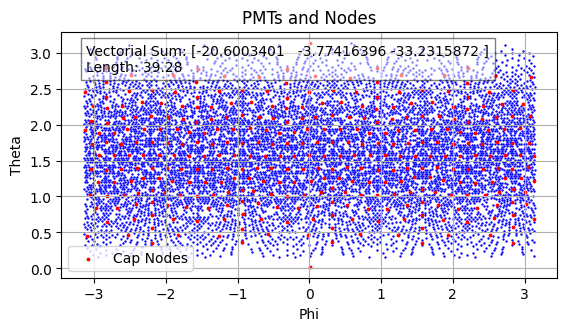

(7389,)
(9389, 3)
(9389, 3)


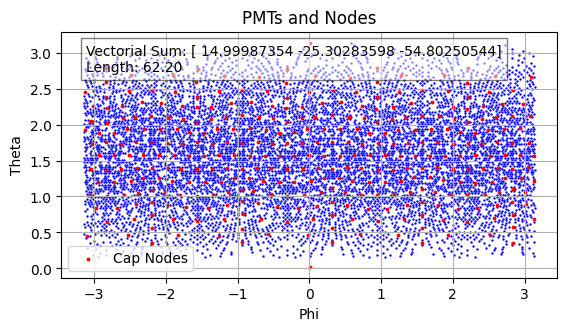

(6889,)
(9389, 3)
(9389, 3)


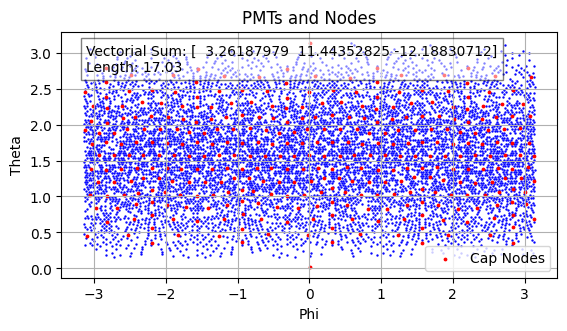

(6389,)
(9389, 3)
(9389, 3)


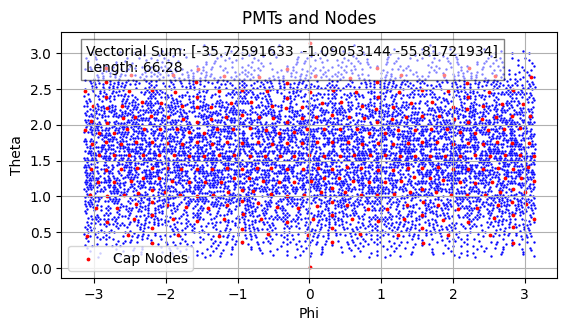

(5889,)
(9389, 3)
(9389, 3)


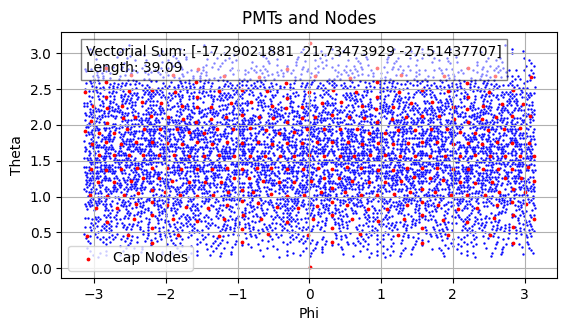

(5389,)
(9389, 3)
(9389, 3)


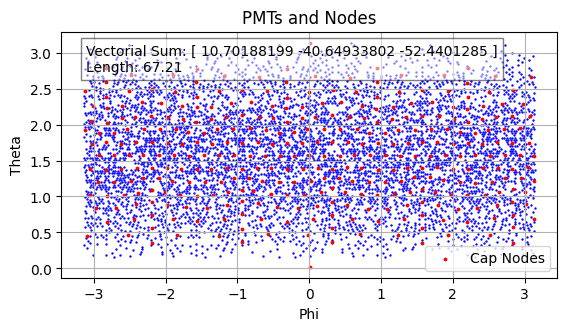

(4889,)
(9389, 3)
(9389, 3)


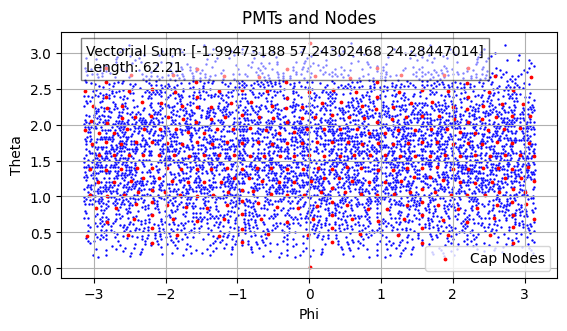

(4389,)
(9389, 3)
(9389, 3)


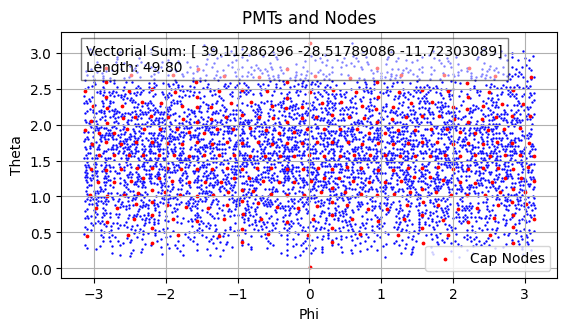

(3889,)
(9389, 3)
(9389, 3)


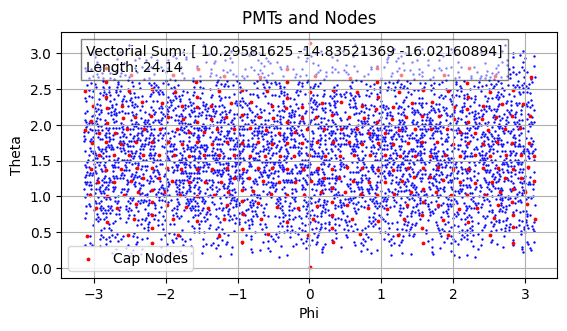

(3389,)
(9389, 3)
(9389, 3)


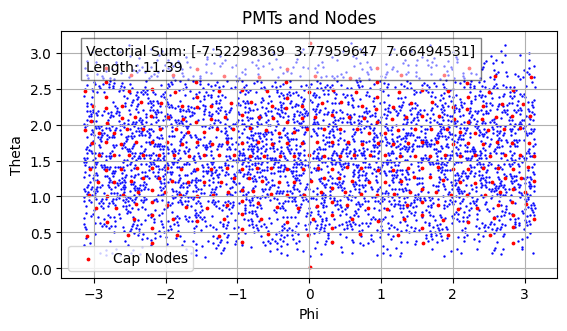

(2389,)
(9389, 3)
(9389, 3)


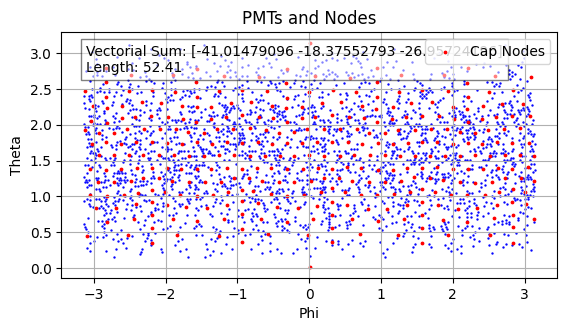

In [46]:
pmtSets = np.arange(1, 30)
all_pos_cart_raw = np.genfromtxt('pmt_positions.csv', delimiter=',', skip_header=1)
all_pos_cart = all_pos_cart_raw / np.linalg.norm(all_pos_cart_raw, axis=1)[:, np.newaxis]
all_pos_sph = convert_points_to_spherical(all_pos_cart)

for pmt_set in pmtSets:
    active_pos_cart, active_pos_sph = get_active_positions(indices_file=f'PMTConfigInfoFiles/PMTSet{pmt_set}_indices.txt',all_pos_cart=all_pos_cart,all_pos_sph=all_pos_sph )

    vector_sum = np.sum(active_pos_cart, axis=0)
    vector_sum_length = np.linalg.norm(vector_sum)

    # Create a new plot of all PMTs and Nodes
    plt.scatter(active_pos_sph[:,1], active_pos_sph[:,2], s=0.5, color='blue')  # Original points
    plt.scatter(nodes_pos_sph[:,1], nodes_pos_sph[:,2], s=3, color='red', label='Cap Nodes')  # Clicked points in red

    plt.xlabel('Phi')
    plt.ylabel('Theta')
    plt.title('PMTs and Nodes')

    # Add a text box with the value of vectorial_sum and its length
    text = f'Vectorial Sum: {vector_sum}\nLength: {vector_sum_length:.2f}'
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, va='top', bbox=dict(facecolor='white', alpha=0.5))

    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True)
    plt.legend()

    plt.savefig(f'PMTSet{str(pmt_set)}_map.pdf', format='pdf')

    plt.show()

    # Add a row to the stats file with 'vector sum norm'
    '''
    stats_file = f'PMTConfigStatsFiles/{run_number}_stats.csv'
    if os.path.exists(stats_file):
        df = pd.read_csv(stats_file)
        # Create a new row with 'vector sum norm' as the first entry and vector_sum_length for all columns
        new_row = ['vector sum norm'] + [vector_sum_length] * (len(df.columns) - 1)
        # Append the new row to the dataframe
        df.loc[len(df)] = new_row
        # Save the updated file
        df.to_csv(stats_file, index=False)'''

In [20]:
file_list = sorted(glob.glob('PMTConfigStatsFiles/*_stats.csv'), key=lambda x: os.path.getmtime(x))
print(file_list)

['PMTConfigStatsFiles/PMTSet1_stats.csv', 'PMTConfigStatsFiles/PMTSet2_stats.csv', 'PMTConfigStatsFiles/PMTSet3_stats.csv', 'PMTConfigStatsFiles/PMTSet4_stats.csv', 'PMTConfigStatsFiles/PMTSet5_stats.csv', 'PMTConfigStatsFiles/PMTSet6_stats.csv', 'PMTConfigStatsFiles/PMTSet7_stats.csv', 'PMTConfigStatsFiles/PMTSet8_stats.csv', 'PMTConfigStatsFiles/PMTSet9_stats.csv', 'PMTConfigStatsFiles/PMTSet10_stats.csv', 'PMTConfigStatsFiles/PMTSet11_stats.csv', 'PMTConfigStatsFiles/PMTSet12_stats.csv', 'PMTConfigStatsFiles/PMTSet13_stats.csv', 'PMTConfigStatsFiles/PMTSet14_stats.csv', 'PMTConfigStatsFiles/PMTSet15_stats.csv', 'PMTConfigStatsFiles/PMTSet16_stats.csv', 'PMTConfigStatsFiles/PMTSet17_stats.csv', 'PMTConfigStatsFiles/PMTSet18_stats.csv', 'PMTConfigStatsFiles/PMTSet19_stats.csv', 'PMTConfigStatsFiles/PMTSet20_stats.csv', 'PMTConfigStatsFiles/PMTSet21_stats.csv', 'PMTConfigStatsFiles/PMTSet22_stats.csv', 'PMTConfigStatsFiles/PMTSet23_stats.csv', 'PMTConfigStatsFiles/PMTSet24_stats.csv', 

In [25]:
alphas = [3, 4, 6, 8, 10]

for alpha in alphas:
    df_list = []

    for file in file_list:
        data = pd.read_csv(file, index_col=0)
        alpha_col = f'alpha = pi/{alpha}'
        column_name = os.path.basename(file).split('_')[0]

        if alpha_col in data.columns:
            df_list.append(data[[alpha_col]].rename(columns={alpha_col: column_name}))

    if df_list:
        final_df = pd.concat(df_list, axis=1)
        final_df.to_csv(f'AlphaPiOver{alpha}.csv')

In [38]:

for alpha in alphas:
    df = pd.read_csv(f'AlphaPiOver{alpha}.csv', index_col=0)

    metrics = ['total N', 'mean', 'median', 'stdev', 'normalized stdev', 'vector sum norm']
    for metric in metrics:
        plt.figure(figsize=(50, 5))
        plt.grid()

        # Set background colors
        plt.axvspan(0, 15.5, facecolor='lightpink', alpha=0.4)
        plt.axvspan(15.5, 29.5, facecolor='lightyellow', alpha=0.4)
        plt.axvspan(29.5, len(df.columns), facecolor='lightblue', alpha=0.4)

        # Plot the data
        plt.plot(df.columns, df.loc[metric], marker='o', label=metric)
        if metric == 'vector sum norm':
            #print(df.columns)
            print(df.loc[metric])
        plt.xlabel('PMT Configuration')
        plt.ylabel(metric)
        plt.title(f'{metric} vs PMT Configuration for alpha = pi/{alpha}')
        plt.legend()

        # Save the plot
        plt.savefig(f'{metric}_alphaPiOver{alpha}.pdf', format='pdf')
        plt.close()

PMTSet1     5.593348e+05
PMTSet2     3.065591e+06
PMTSet3     5.687654e+06
PMTSet4     8.045406e+06
PMTSet5     1.031511e+07
PMTSet6     1.220757e+07
PMTSet7     1.465165e+07
PMTSet8     1.659598e+07
PMTSet9     1.775496e+07
PMTSet10    1.888136e+07
PMTSet11    1.978308e+07
PMTSet12    1.946499e+07
PMTSet13    1.870962e+07
PMTSet14    1.772156e+07
PMTSet15    1.437692e+07
PMTSet16    4.983053e+05
PMTSet17    5.769262e+05
PMTSet18    6.464174e+05
PMTSet19    3.303900e+05
PMTSet20    5.229081e+05
PMTSet21    1.432994e+05
PMTSet22    5.571196e+05
PMTSet23    3.291106e+05
PMTSet24    5.646448e+05
PMTSet25    5.232889e+05
PMTSet26    4.183312e+05
PMTSet27    2.031746e+05
PMTSet28    9.601007e+04
PMTSet29    4.415968e+05
309434      7.801287e+02
302640      1.418738e+03
309504      4.494454e+02
302159      7.581862e+02
355216      3.518352e+02
356009      8.885385e+02
351884      9.130486e+02
351847      9.162379e+02
358123      3.368925e+02
303334      9.510109e+02
311222      4.236489e+02


In [37]:
for alpha in alphas:
    df = pd.read_csv(f'AlphaPiOver{alpha}.csv', index_col=0)

    metric = 'vector sum norm'
    plt.figure(figsize=(50, 5))
    plt.grid()

    # Set background colors
    plt.axvspan(0, 15.5, facecolor='lightpink', alpha=0.4)
    plt.axvspan(15.5, 29.5, facecolor='lightyellow', alpha=0.4)
    plt.axvspan(29.5, len(df.columns), facecolor='lightblue', alpha=0.4)

    # Plot the vector sum norm in log scale
    plt.plot(df.columns, df.loc[metric], marker='o', label=metric)
    plt.yscale('log')  # Set y-axis to log scale

    plt.xlabel('PMT Configuration')
    plt.ylabel(metric)
    plt.title(f'{metric} vs PMT Configuration for alpha = pi/{alpha}')
    plt.legend()

    # Save the plot
    plt.savefig(f'{metric}_Log_alphaPiOver{alpha}.pdf', format='pdf')
    plt.close()
